# RNN vs Transformer — Text Classification
## CO5085 Deep Learning | Assignment 1

**Objective**: Compare RNN (BiLSTM) and Transformer (DistilBERT) on text classification via fine-tuning.

**Dataset**: 20 Newsgroups (20 topics, ~11K train / 7.5K test) or custom dataset from Google Drive.

| Model | Architecture | Pretrained |
|-------|-------------|------------|
| BiLSTM | Bidirectional LSTM — sequential, recurrent | GloVe 6B 100d embeddings |
| DistilBERT | Transformer — bidirectional self-attention | HuggingFace `distilbert-base-uncased` |

**Metrics**: Accuracy, F1-macro, Confusion Matrix, Training Curves

In [5]:
# Install required packages
!pip install -q transformers datasets tqdm


In [6]:
# ============================================================
# CONFIGURATION
# ============================================================

# ---- Shared Google Drive Setup --------------------------------
# STEP 1: Open the shared folder and click 'Add shortcut to Drive':
#   https://drive.google.com/drive/folders/1UVs9LM9N7H_R_cKbr6pNjAGKEgqHzgUp
#
# STEP 2: Place the shortcut in 'My Drive' and name it 'deep-learning-asm01'.
#   Everyone on the team shares the same dataset -- no re-downloading needed.

SHARED_FOLDER  = 'deep-learning-asm01'
GDRIVE_BASE    = f'/content/drive/MyDrive/{SHARED_FOLDER}'
TEXT_DATA_DIR  = f'{GDRIVE_BASE}/data/20newsgroups'   # dataset cache (shared)

# Custom text dataset (CSV: text + label columns), or None for 20 Newsgroups.
GDRIVE_DATASET_PATH = None
# GDRIVE_DATASET_PATH = f'{GDRIVE_BASE}/data/text_dataset'

NUM_CLASSES    = 20
MAX_SEQ_LEN    = 256
MAX_WORDS_RNN  = 128
VOCAB_SIZE     = 50000
EMBED_DIM      = 100
HIDDEN_DIM     = 256
BATCH_SIZE     = 32
EPOCHS_RNN     = 15
EPOCHS_BERT    = 5
LR_RNN         = 1e-3
LR_BERT        = 2e-5
SEED           = 42
BERT_MODEL     = 'distilbert-base-uncased'
SAVE_DIR       = f'{GDRIVE_BASE}/results/rnn_vs_transformer'

import os

print(f'Shared Drive base   : {GDRIVE_BASE}')
print(f'20 Newsgroups cache : {TEXT_DATA_DIR}')
print(f'Results dir         : {SAVE_DIR}')

Shared Drive base   : /content/drive/MyDrive/deep-learning-asm01
20 Newsgroups cache : /content/drive/MyDrive/deep-learning-asm01/data/20newsgroups
Results dir         : /content/drive/MyDrive/deep-learning-asm01/results/rnn_vs_transformer


In [7]:
# Mount Google Drive
from google.colab import drive
if not os.path.isdir('/content/drive/MyDrive'):
    drive.mount('/content/drive')

if os.path.isdir(GDRIVE_BASE):
    os.makedirs(TEXT_DATA_DIR, exist_ok=True)
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f'Shared Drive accessible: {GDRIVE_BASE}')
    USE_SHARED_DRIVE = True
else:
    print(f'WARNING: {GDRIVE_BASE} not found.')
    print('To use the shared dataset:')
    print('  1. Open: https://drive.google.com/drive/folders/1UVs9LM9N7H_R_cKbr6pNjAGKEgqHzgUp')
    print("  2. Add shortcut to Drive -> My Drive -> name it 'deep-learning-asm01'")
    print('Falling back to local /content (not persisted between sessions).')
    TEXT_DATA_DIR = '/content/data/20newsgroups'
    os.makedirs(TEXT_DATA_DIR, exist_ok=True)
    USE_SHARED_DRIVE = False

print(f'20 Newsgroups cache: {TEXT_DATA_DIR}')

Shared Drive accessible: /content/drive/MyDrive/deep-learning-asm01
20 Newsgroups cache: /content/drive/MyDrive/deep-learning-asm01/data/20newsgroups


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import re, time, json, random, warnings
from tqdm import tqdm
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
warnings.filterwarnings('ignore')

def set_seed(s):
    torch.manual_seed(s); torch.cuda.manual_seed(s)
    np.random.seed(s); random.seed(s)

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [9]:
def clean_text(text):
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return ' '.join(text.lower().split())

def load_data():
    global NUM_CLASSES, CLASS_NAMES
    import pickle
    cache_path = os.path.join(TEXT_DATA_DIR, '20newsgroups_cache.pkl')

    if GDRIVE_DATASET_PATH and os.path.exists(GDRIVE_DATASET_PATH):
        print(f'Loading custom dataset from: {GDRIVE_DATASET_PATH}')
        train_df = pd.read_csv(os.path.join(GDRIVE_DATASET_PATH, 'train.csv'))
        test_df  = pd.read_csv(os.path.join(GDRIVE_DATASET_PATH, 'test.csv'))
        le = LabelEncoder()
        train_texts  = [clean_text(t) for t in train_df['text'].tolist()]
        test_texts   = [clean_text(t) for t in test_df['text'].tolist()]
        train_labels = le.fit_transform(train_df['label'].tolist()).tolist()
        test_labels  = le.transform(test_df['label'].tolist()).tolist()
        CLASS_NAMES  = le.classes_.tolist()
        NUM_CLASSES  = len(CLASS_NAMES)
    elif os.path.isfile(cache_path):
        # Load from shared Drive cache -- skip download entirely
        print(f'Loading 20 Newsgroups from shared Drive cache: {cache_path}')
        with open(cache_path, 'rb') as fh:
            data = pickle.load(fh)
        train_texts  = data['train_texts']
        test_texts   = data['test_texts']
        train_labels = data['train_labels']
        test_labels  = data['test_labels']
        CLASS_NAMES  = data['class_names']
        NUM_CLASSES  = len(CLASS_NAMES)
    else:
        print('Downloading 20 Newsgroups...')
        train_raw = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
        test_raw  = fetch_20newsgroups(subset='test',  remove=('headers', 'footers', 'quotes'))
        train_texts  = [clean_text(t) for t in train_raw.data]
        test_texts   = [clean_text(t) for t in test_raw.data]
        train_labels = train_raw.target.tolist()
        test_labels  = test_raw.target.tolist()
        CLASS_NAMES  = train_raw.target_names
        NUM_CLASSES  = len(CLASS_NAMES)
        # Save to shared Drive so teammates can reuse without re-downloading
        os.makedirs(TEXT_DATA_DIR, exist_ok=True)
        with open(cache_path, 'wb') as fh:
            pickle.dump({'train_texts': train_texts, 'test_texts': test_texts,
                         'train_labels': train_labels, 'test_labels': test_labels,
                         'class_names': CLASS_NAMES}, fh)
        print(f'20 Newsgroups cached to shared Drive: {cache_path}')

    print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES[:5]}...')
    print(f'Train: {len(train_texts):,}  |  Test: {len(test_texts):,}')
    return train_texts, test_texts, train_labels, test_labels

train_texts, test_texts, train_labels, test_labels = load_data()

Loading 20 Newsgroups from shared Drive cache: /content/drive/MyDrive/deep-learning-asm01/data/20newsgroups/20newsgroups_cache.pkl
Classes (20): ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']...
Train: 11,314  |  Test: 7,532


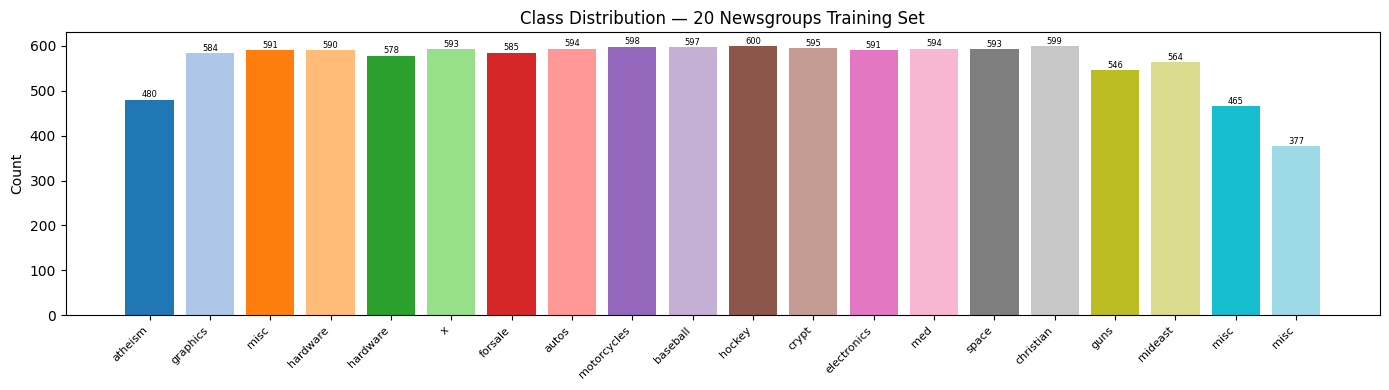

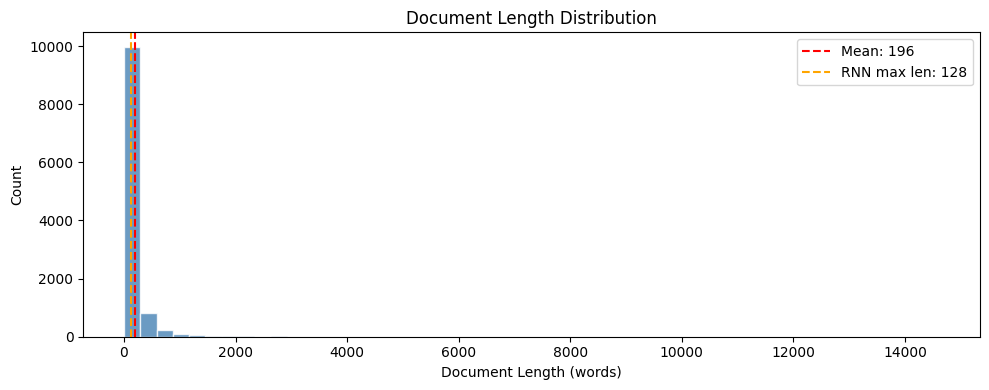

Avg length: 196 | Median: 83 | Max: 14613


In [10]:
# ── EDA ──────────────────────────────────────────────────────
# Class distribution
counts = pd.Series(train_labels).value_counts().sort_index()
plt.figure(figsize=(14, 4))
bars = plt.bar(range(NUM_CLASSES), counts.values, color=plt.cm.tab20.colors[:NUM_CLASSES])
plt.xticks(range(NUM_CLASSES),
           [CLASS_NAMES[i].split('.')[-1] for i in range(NUM_CLASSES)],
           rotation=45, ha='right', fontsize=8)
plt.ylabel('Count'); plt.title('Class Distribution — 20 Newsgroups Training Set')
for bar, c in zip(bars, counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(c),
             ha='center', fontsize=6)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=120, bbox_inches='tight'); plt.show()

# Text length distribution
lengths = [len(t.split()) for t in train_texts]
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.0f}')
plt.axvline(MAX_WORDS_RNN, color='orange', linestyle='--', label=f'RNN max len: {MAX_WORDS_RNN}')
plt.xlabel('Document Length (words)'); plt.ylabel('Count')
plt.title('Document Length Distribution')
plt.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/text_lengths.png', dpi=120, bbox_inches='tight'); plt.show()
print(f'Avg length: {np.mean(lengths):.0f} | Median: {np.median(lengths):.0f} | Max: {max(lengths)}')


In [11]:
# ── BiLSTM Preprocessing: Vocabulary & Tokenizer ─────────────
def build_vocab(texts, max_vocab=VOCAB_SIZE):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = ['<PAD>', '<UNK>'] + [w for w, _ in counter.most_common(max_vocab - 2)]
    word2idx = {w: i for i, w in enumerate(vocab)}
    return word2idx

def tokenize_rnn(text, word2idx, max_len=MAX_WORDS_RNN):
    tokens = [word2idx.get(w, 1) for w in text.split()[:max_len]]
    tokens += [0] * (max_len - len(tokens))  # pad
    return tokens

word2idx = build_vocab(train_texts)
print(f'Vocabulary size: {len(word2idx):,}')

class RNNTextDataset(Dataset):
    def __init__(self, texts, labels):
        self.x = [torch.tensor(tokenize_rnn(t, word2idx)) for t in texts]
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]

rnn_train_ds = RNNTextDataset(train_texts, train_labels)
rnn_test_ds  = RNNTextDataset(test_texts,  test_labels)
rnn_train_loader = DataLoader(rnn_train_ds, BATCH_SIZE, shuffle=True,  num_workers=2)
rnn_test_loader  = DataLoader(rnn_test_ds,  BATCH_SIZE, shuffle=False, num_workers=2)
print(f'RNN Train: {len(rnn_train_ds):,}  |  Test: {len(rnn_test_ds):,}')


Vocabulary size: 50,000
RNN Train: 11,314  |  Test: 7,532


In [12]:
# ── DistilBERT Preprocessing ─────────────────────────────────
tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)

class BERTTextDataset(Dataset):
    def __init__(self, texts, labels):
        enc = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=MAX_SEQ_LEN,
            return_tensors='pt'
        )
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels         = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {
            'input_ids':      self.input_ids[i],
            'attention_mask': self.attention_mask[i],
            'labels':         self.labels[i]
        }

bert_train_ds = BERTTextDataset(train_texts, train_labels)
bert_test_ds  = BERTTextDataset(test_texts,  test_labels)
bert_train_loader = DataLoader(bert_train_ds, BATCH_SIZE, shuffle=True,  num_workers=2)
bert_test_loader  = DataLoader(bert_test_ds,  BATCH_SIZE, shuffle=False, num_workers=2)
print(f'BERT Train: {len(bert_train_ds):,}  |  Test: {len(bert_test_ds):,}')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT Train: 11,314  |  Test: 7,532


In [13]:
# ── BiLSTM Model ─────────────────────────────────────────────
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, (hn, _) = self.lstm(emb)
        # Concatenate final forward and backward hidden states
        hn = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.fc(self.dropout(hn))

bilstm_model = BiLSTMClassifier(
    vocab_size=len(word2idx),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES
).to(device)

total = sum(p.numel() for p in bilstm_model.parameters())
print(f'BiLSTM: {total/1e6:.2f}M parameters')


BiLSTM: 7.45M parameters


In [14]:
# ── DistilBERT Model ─────────────────────────────────────────
bert_model = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=NUM_CLASSES
).to(device)

total = sum(p.numel() for p in bert_model.parameters())
print(f'DistilBERT: {total/1e6:.1f}M parameters')


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT: 67.0M parameters


In [15]:
# ── Training Functions ───────────────────────────────────────
@torch.no_grad()
def eval_model(model, loader, is_bert=False):
    model.eval()
    preds_all, labels_all = [], []
    for batch in tqdm(loader, leave=False, desc='  eval'):
        if is_bert:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['labels'].to(device)
            out = model(input_ids=input_ids, attention_mask=attn_mask)
            logits = out.logits
        else:
            x, labels = batch[0].to(device), batch[1].to(device)
            logits = model(x)
        preds_all.extend(logits.argmax(1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average='macro', zero_division=0)
    return acc, f1, preds_all, labels_all

def train_bilstm(model, train_loader, test_loader, epochs=EPOCHS_RNN, lr=LR_RNN):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    hist = {k: [] for k in ['tr_loss','tr_acc','val_acc','val_f1']}
    best_acc, best_state = 0.0, None
    t0 = time.time()
    print(f'\n{"="*60}\nTraining BiLSTM ({epochs} epochs)\n{"="*60}')
    for ep in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in tqdm(train_loader, leave=False, desc='  train'):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        scheduler.step()
        tr_loss = total_loss / total
        tr_acc  = correct / total
        val_acc, val_f1, _, _ = eval_model(model, test_loader)
        for k, v in zip(['tr_loss','tr_acc','val_acc','val_f1'], [tr_loss, tr_acc, val_acc, val_f1]):
            hist[k].append(v)
        if val_acc > best_acc:
            best_acc  = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        star = ' *' if val_acc >= best_acc else ''
        print(f'  Ep {ep:>2}/{epochs} | loss={tr_loss:.4f} tr_acc={tr_acc:.4f} val_acc={val_acc:.4f} f1={val_f1:.4f}{star}')
    elapsed = time.time() - t0
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    torch.save(best_state, f'{SAVE_DIR}/best_BiLSTM.pth')
    print(f'\nFinished in {elapsed/60:.1f} min | Best val acc: {best_acc:.4f}')
    return hist, elapsed

def train_bert(model, train_loader, test_loader, epochs=EPOCHS_BERT, lr=LR_BERT):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps
    )
    hist = {k: [] for k in ['tr_loss','tr_acc','val_acc','val_f1']}
    best_acc, best_state = 0.0, None
    t0 = time.time()
    print(f'\n{"="*60}\nTraining DistilBERT ({epochs} epochs)\n{"="*60}')
    for ep in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for batch in tqdm(train_loader, leave=False, desc='  train'):
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['labels'].to(device)
            optimizer.zero_grad()
            out  = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
            loss = out.loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            total_loss += loss.item() * labels.size(0)
            correct += (out.logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
        tr_loss = total_loss / total
        tr_acc  = correct / total
        val_acc, val_f1, _, _ = eval_model(model, test_loader, is_bert=True)
        for k, v in zip(['tr_loss','tr_acc','val_acc','val_f1'], [tr_loss, tr_acc, val_acc, val_f1]):
            hist[k].append(v)
        if val_acc > best_acc:
            best_acc  = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        star = ' *' if val_acc >= best_acc else ''
        print(f'  Ep {ep:>2}/{epochs} | loss={tr_loss:.4f} tr_acc={tr_acc:.4f} val_acc={val_acc:.4f} f1={val_f1:.4f}{star}')
    elapsed = time.time() - t0
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    torch.save(best_state, f'{SAVE_DIR}/best_DistilBERT.pth')
    print(f'\nFinished in {elapsed/60:.1f} min | Best val acc: {best_acc:.4f}')
    return hist, elapsed


In [16]:
# ── Train BiLSTM ─────────────────────────────────────────────
rnn_hist, rnn_time = train_bilstm(bilstm_model, rnn_train_loader, rnn_test_loader)



Training BiLSTM (15 epochs)


  Ep  1/15 | loss=2.8757 tr_acc=0.0924 val_acc=0.1198 f1=0.0659 *


  Ep  2/15 | loss=2.6440 tr_acc=0.1435 val_acc=0.1463 f1=0.1052 *


  Ep  3/15 | loss=2.4529 tr_acc=0.1932 val_acc=0.1981 f1=0.1754 *


  Ep  4/15 | loss=2.2428 tr_acc=0.2642 val_acc=0.2515 f1=0.2229 *


...

  Ep 11/15 | loss=0.9758 tr_acc=0.6733 val_acc=0.4468 f1=0.4366 *


  Ep 12/15 | loss=0.9005 tr_acc=0.6951 val_acc=0.4517 f1=0.4414 *


  Ep 13/15 | loss=0.8315 tr_acc=0.7218 val_acc=0.4685 f1=0.4563 *


  Ep 14/15 | loss=0.7903 tr_acc=0.7358 val_acc=0.4680 f1=0.4574


  Ep 15/15 | loss=0.7705 tr_acc=0.7430 val_acc=0.4685 f1=0.4586 *

Finished in 1.1 min | Best val acc: 0.4685


In [17]:
# ── Train DistilBERT ─────────────────────────────────────────
bert_hist, bert_time = train_bert(bert_model, bert_train_loader, bert_test_loader)



Training DistilBERT (5 epochs)


  Ep  1/5 | loss=2.1461 tr_acc=0.4302 val_acc=0.6433 f1=0.6139 *


  Ep  2/5 | loss=1.0585 tr_acc=0.7021 val_acc=0.6792 f1=0.6546 *


  Ep  3/5 | loss=0.7720 tr_acc=0.7744 val_acc=0.6942 f1=0.6712 *


  Ep  4/5 | loss=0.6211 tr_acc=0.8229 val_acc=0.6969 f1=0.6758 *


  Ep  5/5 | loss=0.5386 tr_acc=0.8496 val_acc=0.6970 f1=0.6802 *

Finished in 2.0 min | Best val acc: 0.6970


In [18]:
# ── Final Evaluation & Comparison ───────────────────────────
rnn_acc,  rnn_f1,  rnn_preds,  rnn_labels  = eval_model(bilstm_model, rnn_test_loader,  is_bert=False)
bert_acc, bert_f1, bert_preds, bert_labels  = eval_model(bert_model,   bert_test_loader, is_bert=True)

df_res = pd.DataFrame({
    'Model':         ['BiLSTM', 'DistilBERT'],
    'Architecture':  ['RNN (Bidirectional LSTM)', 'Transformer'],
    'Accuracy':      [f'{rnn_acc:.4f}',  f'{bert_acc:.4f}'],
    'F1-macro':      [f'{rnn_f1:.4f}',   f'{bert_f1:.4f}'],
    'Params (M)':    [
        f'{sum(p.numel() for p in bilstm_model.parameters())/1e6:.2f}',
        f'{sum(p.numel() for p in bert_model.parameters())/1e6:.1f}'
    ],
    'Train Time (min)': [f'{rnn_time/60:.1f}', f'{bert_time/60:.1f}'],
})
print('\n' + '='*65 + '\nFINAL COMPARISON RESULTS\n' + '='*65)
print(df_res.to_string(index=False))
df_res.to_csv(f'{SAVE_DIR}/comparison.csv', index=False)
print(f'\nSaved: {SAVE_DIR}/comparison.csv')



FINAL COMPARISON RESULTS
     Model             Architecture Accuracy F1-macro Params (M) Train Time (min)
    BiLSTM RNN (Bidirectional LSTM)   0.4685   0.4563       7.45              1.1
DistilBERT              Transformer   0.6970   0.6802       67.0              2.0

Saved: /content/drive/MyDrive/deep-learning-asm01/results/rnn_vs_transformer/comparison.csv


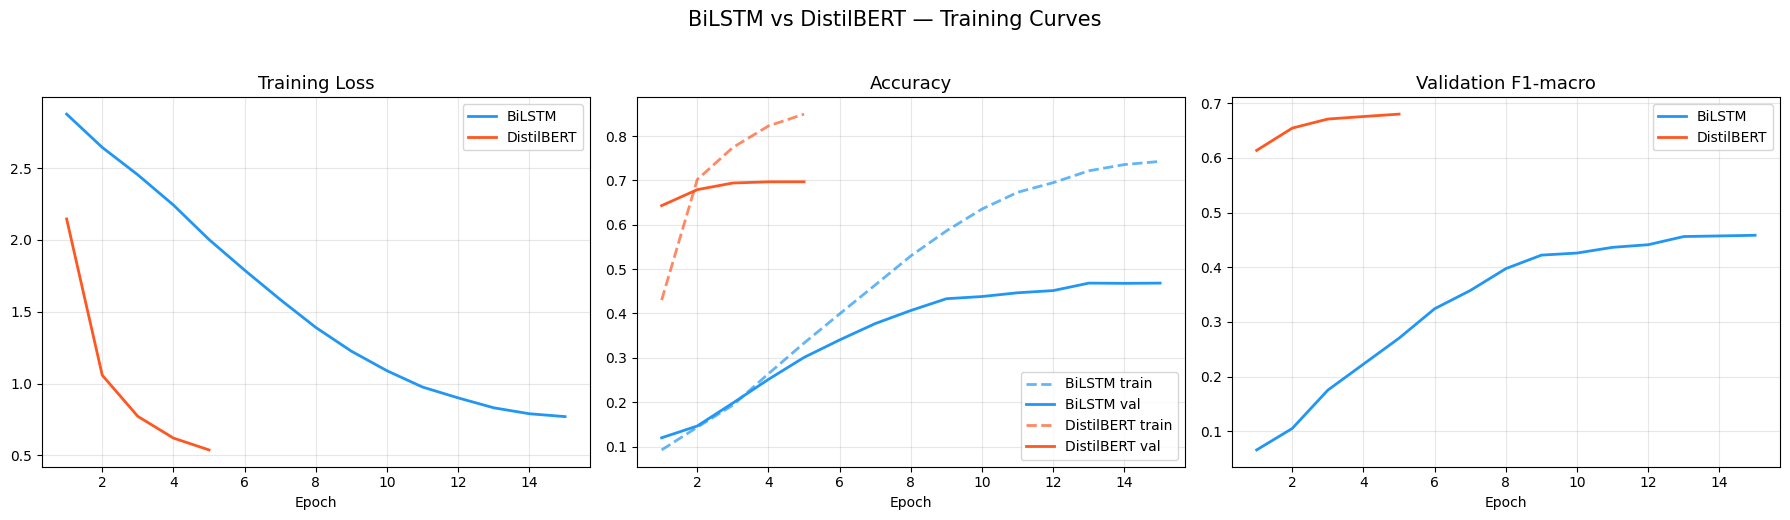

In [19]:
# Shared plot setup (used across all visualization cells)
colors = ['#2196F3', '#FF5722']
names  = ['BiLSTM', 'DistilBERT']
display_cls = [CLASS_NAMES[i].split('.')[-1] for i in range(NUM_CLASSES)]

# 1) Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for hist, c, n in zip([rnn_hist, bert_hist], colors, names):
    ep = range(1, len(hist['val_acc']) + 1)

    axes[0].plot(ep, hist['tr_loss'], '-', color=c, label=n, linewidth=2)
    axes[1].plot(ep, hist['tr_acc'], '--', color=c, alpha=0.7, label=f'{n} train', linewidth=2)
    axes[1].plot(ep, hist['val_acc'], '-', color=c, label=f'{n} val', linewidth=2)
    axes[2].plot(ep, hist['val_f1'], '-', color=c, label=n, linewidth=2)

for ax, t in zip(axes, ['Training Loss', 'Accuracy', 'Validation F1-macro']):
    ax.set_title(t, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('BiLSTM vs DistilBERT — Training Curves', fontsize=15, y=1.03)
fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

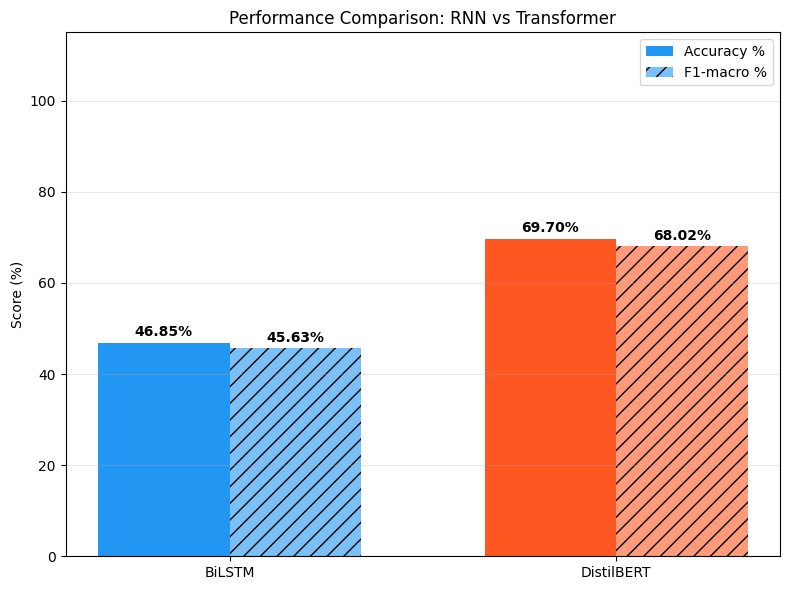

In [20]:
# 2) Bar comparison
x = np.arange(2)
w = 0.34

fig, ax = plt.subplots(figsize=(8, 6))

b1 = ax.bar(
    x - w/2,
    [rnn_acc * 100, bert_acc * 100],
    w,
    label='Accuracy %',
    color=colors
)

b2 = ax.bar(
    x + w/2,
    [rnn_f1 * 100, bert_f1 * 100],
    w,
    label='F1-macro %',
    color=colors,
    alpha=0.6,
    hatch='//'
)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)')
ax.set_title('Performance Comparison: RNN vs Transformer')
ax.legend()
ax.grid(alpha=0.3, axis='y')

for bar in list(b1) + list(b2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f'{bar.get_height():.2f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

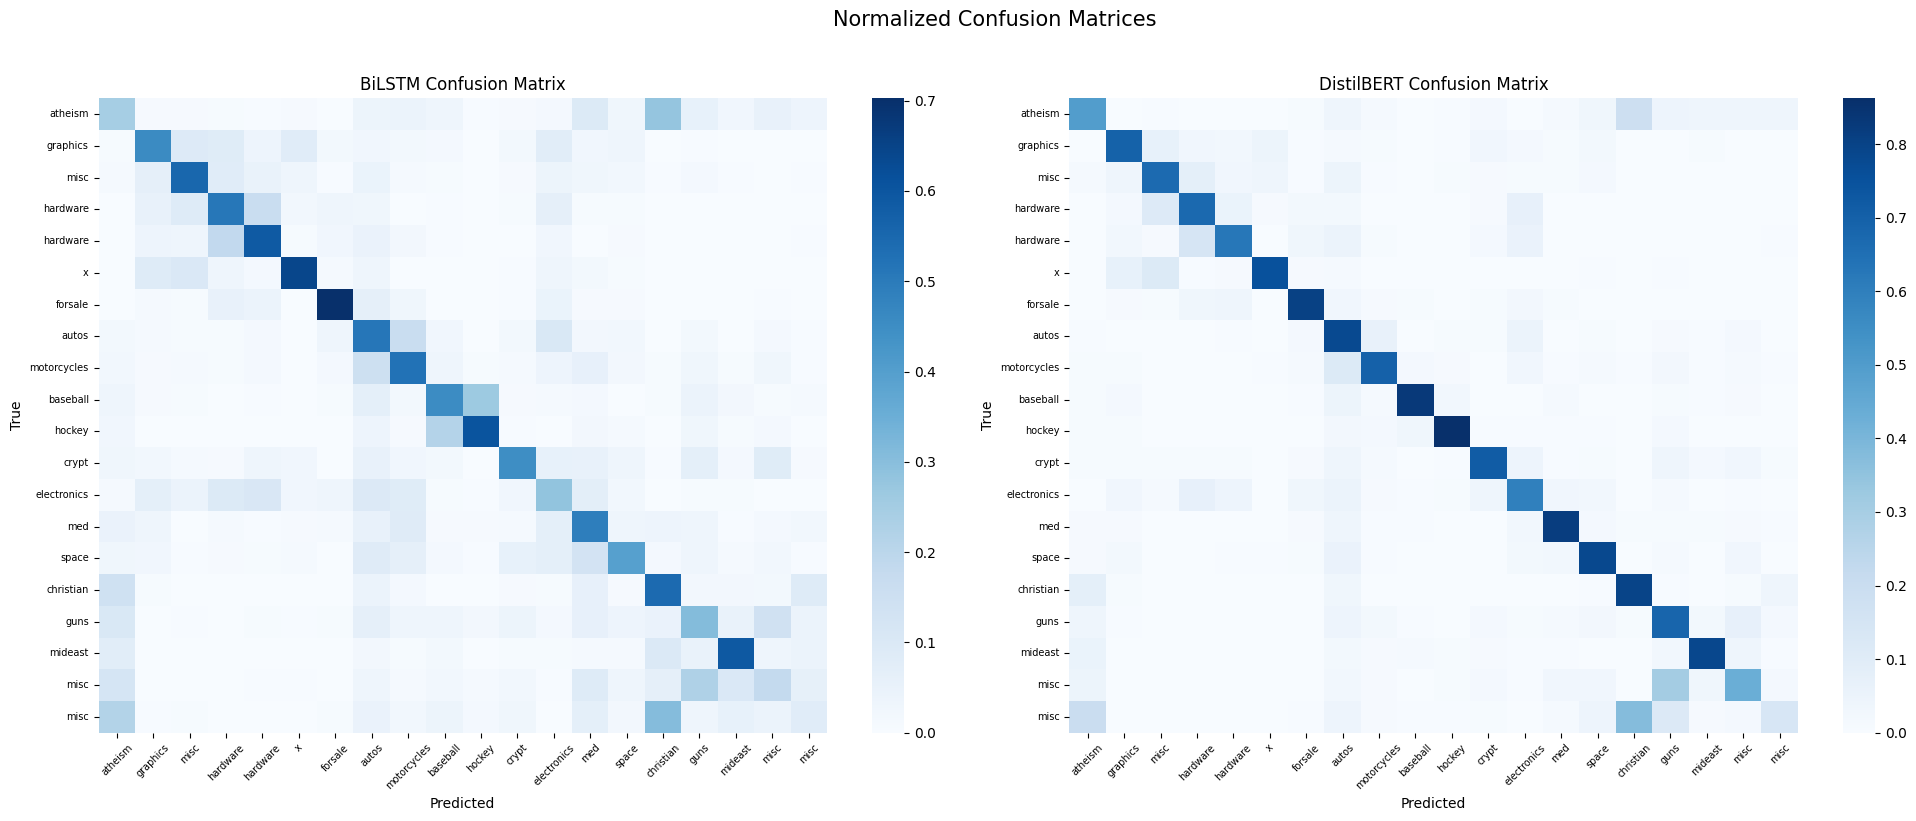

In [21]:
# 3) Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, preds, labels, n in zip(
    axes,
    [rnn_preds, bert_preds],
    [rnn_labels, bert_labels],
    names
):
    cm = confusion_matrix(labels, preds).astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    cm = cm / row_sums

    sns.heatmap(
        cm,
        annot=False,
        cmap='Blues',
        xticklabels=display_cls,
        yticklabels=display_cls,
        ax=ax,
        cbar=True
    )

    ax.set_title(f'{n} Confusion Matrix', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Normalized Confusion Matrices', fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

In [22]:
# ── Classification Reports ───────────────────────────────────
short_names = [n.split('.')[-1] for n in CLASS_NAMES]
for n, p, l in [('BiLSTM', rnn_preds, rnn_labels), ('DistilBERT', bert_preds, bert_labels)]:
    print(f'\n{"="*60}\n{n} — Classification Report\n{"="*60}')
    print(classification_report(l, p, target_names=short_names, digits=4))



BiLSTM — Classification Report
              precision    recall  f1-score   support

     atheism     0.2000    0.2445    0.2200       319
    graphics     0.5000    0.4576    0.4779       389
        misc     0.5619    0.5533    0.5575       394
    hardware     0.4651    0.5102    0.4866       392
    hardware     0.5279    0.5896    0.5571       385
           x     0.7299    0.6430    0.6837       395
     forsale     0.7675    0.7026    0.7336       390
       autos     0.3406    0.5126    0.4093       396
 motorcycles     0.4483    0.5226    0.4826       398
    baseball     0.4865    0.4534    0.4694       397
      hockey     0.6410    0.6040    0.6219       399
       crypt     0.6138    0.4495    0.5190       396
 electronics     0.2955    0.2850    0.2902       393
         med     0.3877    0.4924    0.4338       396
       space     0.5270    0.3959    0.4522       394
   christian     0.4402    0.5452    0.4871       398
        guns     0.3228    0.3077    0.3150      

## Analysis & Conclusions

This notebook compares two text-classification approaches on the **20 Newsgroups** dataset: a BiLSTM-based RNN and DistilBERT. The final results show a clear advantage for DistilBERT: **69.70% accuracy / 0.6802 F1-macro** versus **46.85% accuracy / 0.4563 F1-macro** for BiLSTM. In exchange for that gain, DistilBERT is substantially larger (67.0M vs 7.45M parameters) and takes longer to train (2.0 min vs 1.1 min).

---

### Model Comparison

| Model | Architecture | Input Handling | Main Strength | Trade-off |
|-------|-------------|----------------|---------------|-----------|
| BiLSTM | RNN (Bidirectional LSTM) | Sequential processing over tokenized text | Smaller model, lower training cost | Lower accuracy; weaker long-context modelling |
| DistilBERT | Transformer | Self-attention over the full token window | Strong contextual understanding from pretrained representations | Much larger model; heavier computation |

---

### Key Observations

**1. DistilBERT performs substantially better on this task.**

The gap is large in *both* headline metrics, not just one. DistilBERT improves accuracy from 0.4685 to 0.6970 and F1-macro from 0.4563 to 0.6802, indicating better classification quality across all 20 categories — not merely stronger performance on a few dominant classes.

**2. The decisive factor is pretrained contextual representations.**

DistilBERT is initialised from the `distilbert-base-uncased` checkpoint and fine-tuned for 20-way classification, giving it a strong starting point before any downstream training begins. By contrast, the BiLSTM model uses a standard `nn.Embedding(...)` layer trained from scratch; although the assignment header references GloVe 6B 100d embeddings, the actual notebook code does not load pretrained weights into that layer. As a result, DistilBERT benefits from transfer learning while BiLSTM learns its representations entirely from the training data.

**3. BiLSTM is more lightweight, but its representational power is more limited.**

With 7.45M parameters — roughly 9× fewer than DistilBERT — BiLSTM trains faster and has a smaller memory footprint. However, the lower parameter count and the absence of pretrained language knowledge limit its ability to match Transformer performance on a 20-class news classification problem.

**4. Training dynamics reflect the architectural difference.**

BiLSTM is trained for 15 epochs and improves gradually; DistilBERT is trained for only 5 epochs yet reaches much higher validation performance, indicating faster and more efficient convergence. This is consistent with the well-established behaviour of fine-tuned Transformer models: they start from a strong initialisation and adapt quickly.

**5. Visualisation corroborates the scalar metrics.**

The training curves, bar comparison, and normalised confusion matrices all support the same conclusion. DistilBERT's curves converge faster and to a higher plateau; its confusion matrix shows fewer and less severe off-diagonal errors, confirming that the Transformer model separates the 20 newsgroup categories more effectively overall.

---

### Conclusion

DistilBERT is the stronger model for 20 Newsgroups text classification. Its pretrained Transformer encoder provides richer contextual representations and delivers a large performance improvement over the BiLSTM baseline in both accuracy and F1-macro. BiLSTM remains attractive when model size and training cost are the primary constraints, but in this experiment it cannot close the gap in either metric.

The result strongly suggests that, for this dataset and implementation, **transfer learning is the decisive factor** — and that sequential RNN architectures face a fundamental disadvantage against Transformer-based models pretrained on large-scale text corpora.